# RAG and Embedding Models

LLMs are trained on a fixed dataset and have a knowledge cutoff. What happens when we ask them about something they haven't seen? Let's find out.

In [1]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

# This model is 6GB, so it may take a bit to download if you run this yourself.
model_name = "Qwen/Qwen2.5-3B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

In [35]:
question = "What is the course schedule for INFO 4940 at Cornell University?"

messages = [{"role": "user", "content": question}]
inputs = tokenizer.apply_chat_template(messages, return_tensors="pt", add_generation_prompt=True)

model.eval()
with torch.no_grad():
    output = model.generate(**inputs, max_new_tokens=200)

print(tokenizer.decode(output[0][inputs['input_ids'].shape[-1]:], skip_special_tokens=True))

I don't have real-time access to specific course schedules or syllabi, including those for INFO 4940 at Cornell University. Course schedules can change from year to year, and I don't have the capability to browse through university databases or websites.

However, you can typically find the most accurate and up-to-date information about a course's schedule and requirements by:

1. Checking Cornell University's official course catalog or website.
2. Contacting the department directly if you need more detailed information.
3. Looking on Cornell's Canvas learning management system, as courses are often posted there.
4. Speaking with your academic advisor or the professor teaching the course.

If you provide me with more details such as the semester or term you're interested in, I might be able to offer some general guidance or point you towards where you can find this information.


The model can't know this information because it wasn't in its training data. Ideally, the model will tell you that it doesn't know, but sometimes it will *hallucinate*, generate information that is untrue. By the end of today, you'll know one way to potentially fix this. The technique is called **Retrieval-Augmented Generation (RAG)**: instead of relying solely on what the model "knows," we retrieve relevant documents and include them in the prompt.

## From Token Embeddings to Sentence Embeddings

In a previous lecture, we saw that an embedding layer maps each token ID to a dense vector. These vectors are learned during training and capture something about each token's meaning.

But what if we want a single vector that represents an entire sentence or paragraph? We can't just look up one token. Instead, we need to somehow combine all of the token representations into one.

This is exactly what **embedding models** (or **text embedding models**) do. Unlike GPT-2 or Qwen, which are *decoder-only* models designed to generate text, embedding models are typically *encoder* models (like BERT) that are trained specifically to produce useful sentence-level representations. You give them a sentence, and they give you back a single vector that captures its meaning.

## Building Sentence Embeddings

Let's start by building sentence embeddings using Hugging Face. We'll load a popular embedding model, `all-MiniLM-L6-v2`, using `AutoModel`. Notice that we're using `AutoModel` here instead of `AutoModelForCausalLM` — this gives us the raw encoder without a task-specific head
(linear layer) on top. Instead of logits, we'll get hidden states: one vector per token in the input.

In [3]:
from transformers import AutoModel, AutoTokenizer

emb_model_name = "sentence-transformers/all-MiniLM-L6-v2"
emb_tokenizer = AutoTokenizer.from_pretrained(emb_model_name)
emb_model = AutoModel.from_pretrained(emb_model_name)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Let's tokenize a few sentences and see what the model gives us back.

In [4]:
sentences = [
    "The weather in Ithaca is cold.",
    "Ithaca winters are freezing.",
    "Python is a programming language."
]

encoded = emb_tokenizer(sentences, padding=True, truncation=True, return_tensors="pt")

emb_model.eval()
with torch.no_grad():
    output = emb_model(**encoded)

print("Input shape:", encoded["input_ids"].shape)
print("Output shape:", output.last_hidden_state.shape)

Input shape: torch.Size([3, 9])
Output shape: torch.Size([3, 9, 384])


### What are hidden states?

Remember that in the transformer architecture, each layer takes in a sequence of vectors, runs attention (mixing *across* the sequence) and an MLP (mixing *within* each vector), and produces an updated sequence of vectors. These updated vectors are called **hidden states**.

The `last_hidden_state` we see here is the output of the model's final transformer layer. Each token in the input gets its own $D$-dimensional vector, and critically, these vectors are **contextualized**: they depend on the surrounding tokens, not just the token itself. This is unlike the raw embedding layer, which always maps the same token ID to the same vector regardless of context.

In a decoder-only model like GPT-2, these hidden states get multiplied by the embedding matrix to produce logits over the vocabulary for next-token prediction. Here, we're using `AutoModel` instead of `AutoModelForCausalLM`, so there's no language modeling head — we get the raw hidden states directly.

Let's see this in action. We'll look at the hidden states for a single sentence and verify that the same word gets different representations depending on its context.

In [11]:
context_sentences = [
    "I saw my footprints in the sand on the river bank.",
    "I withdrew some cash from my local bank."
]

ctx_encoded = emb_tokenizer(context_sentences, padding=True, truncation=True, return_tensors="pt")

with torch.no_grad():
    ctx_output = emb_model(**ctx_encoded)

# Find the position of "bank" in each sentence
for i, sent in enumerate(context_sentences):
    tokens = emb_tokenizer.convert_ids_to_tokens(ctx_encoded["input_ids"][i])
    print(f"Sentence: {sent}")
    print(f"Tokens: {tokens}")
    bank_pos = tokens.index("bank")
    bank_hidden = ctx_output.last_hidden_state[i, bank_pos]
    print(f"'bank' is at position {bank_pos}, hidden state shape: {bank_hidden.shape}")
    print()

# Compare the two "bank" representations
bank_pos_1 = emb_tokenizer.convert_ids_to_tokens(ctx_encoded["input_ids"][0]).index("bank")
bank_pos_2 = emb_tokenizer.convert_ids_to_tokens(ctx_encoded["input_ids"][1]).index("bank")

bank_1 = ctx_output.last_hidden_state[0, bank_pos_1]
bank_2 = ctx_output.last_hidden_state[1, bank_pos_2]

sim = (bank_1 @ bank_2) / (bank_1.norm() * bank_2.norm())
print(f"Cosine similarity between 'bank' in the two sentences: {sim.item():.4f}")
print("(If the representations were identical, this would be 1.0)")

Sentence: I saw my footprints in the sand on the river bank.
Tokens: ['[CLS]', 'i', 'saw', 'my', 'footprints', 'in', 'the', 'sand', 'on', 'the', 'river', 'bank', '.', '[SEP]']
'bank' is at position 11, hidden state shape: torch.Size([384])

Sentence: I withdrew some cash from my local bank.
Tokens: ['[CLS]', 'i', 'withdrew', 'some', 'cash', 'from', 'my', 'local', 'bank', '.', '[SEP]', '[PAD]', '[PAD]', '[PAD]']
'bank' is at position 8, hidden state shape: torch.Size([384])

Cosine similarity between 'bank' in the two sentences: 0.7466
(If the representations were identical, this would be 1.0)


The output has shape $(B, L, D)$: one vector per token in each sequence. To get a single vector per sentence, we need to combine these token-level representations. The standard approach is **mean pooling**: average the token embeddings, ignoring padding tokens (using the attention mask).

In [6]:
def mean_pool(model_output, attention_mask):
    token_embeddings = model_output.last_hidden_state
    mask_expanded = attention_mask.unsqueeze(-1).float()
    return (token_embeddings * mask_expanded).sum(dim=1) / mask_expanded.sum(dim=1)

with torch.no_grad():
    embeddings = mean_pool(output, encoded["attention_mask"])

print("Sentence embedding shape:", embeddings.shape)

Sentence embedding shape: torch.Size([3, 384])


### Cosine Similarity

Now that we have sentence embeddings, we can measure how similar two sentences are. Cosine similarity measures the cosine of the angle between two vectors:

$$\text{cosine\_similarity}(\mathbf{a}, \mathbf{b}) = \frac{\mathbf{a} \cdot \mathbf{b}}{||\mathbf{a}|| \cdot ||\mathbf{b}||}$$

A value of 1 means the vectors point in the same direction (very similar), 0 means they're orthogonal (unrelated), and -1 means they point in opposite directions.

In [7]:
def cosine_similarity(a, b):
    return (a @ b) / (a.norm() * b.norm())

print("Similar sentences (cold / freezing):",
      cosine_similarity(embeddings[0], embeddings[1]).item())
print("Unrelated sentences (cold / programming):",
      cosine_similarity(embeddings[0], embeddings[2]).item())

Similar sentences (cold / freezing): 0.8573700785636902
Unrelated sentences (cold / programming): 0.13399626314640045


Let's embed a few more sentences and look at the full similarity matrix.

<Axes: >

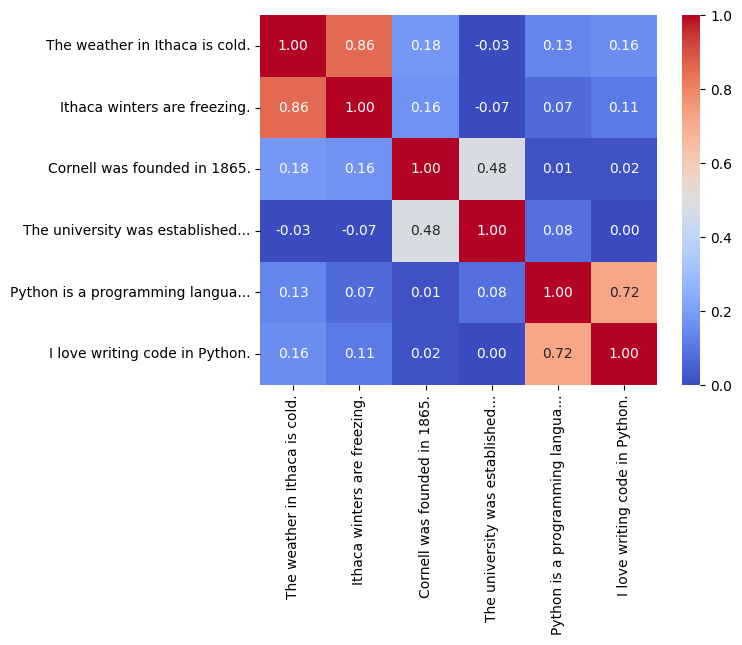

In [8]:
import pandas as pd
import seaborn as sns

all_sentences = [
    "The weather in Ithaca is cold.",
    "Ithaca winters are freezing.",
    "Cornell was founded in 1865.",
    "The university was established in the 19th century.",
    "Python is a programming language.",
    "I love writing code in Python.",
]

encoded_all = emb_tokenizer(all_sentences, padding=True, truncation=True, return_tensors="pt")

with torch.no_grad():
    output_all = emb_model(**encoded_all)
    all_embeddings = mean_pool(output_all, encoded_all["attention_mask"])

# Normalize embeddings
all_embeddings = all_embeddings / all_embeddings.norm(dim=1, keepdim=True)

# Compute pairwise cosine similarity (with normalized vectors, this is just a matmul)
sim_matrix = all_embeddings @ all_embeddings.T

labels = [s[:30] + "..." if len(s) > 30 else s for s in all_sentences]

sns.heatmap(
    sim_matrix.numpy(),
    xticklabels=labels,
    yticklabels=labels,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=0,
    vmax=1
)

Notice how the model clusters semantically similar sentences together: the two sentences about cold weather are similar to each other, the two sentences about Cornell's founding are similar, and the two about Python are similar — even though they use different words. This is the power of learned representations: the model has learned that "cold" and "freezing" are related concepts, not just that they share characters.

### Why not just use keyword matching?

You might be wondering whether we really need learned embeddings for this. A simpler approach would be to compare sentences based on word overlap: count which words appear in each sentence, and measure similarity using those counts. This is exactly what **TF-IDF** (Term Frequency-Inverse Document Frequency) does. Let's compare it to our embedding-based similarity on the same sentences.

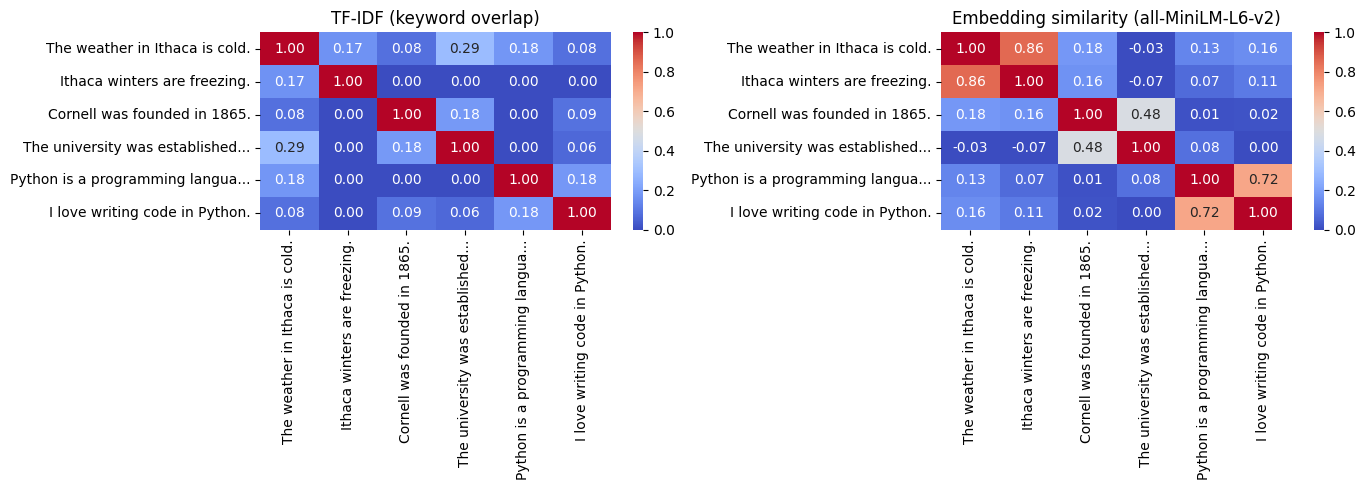

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity as sklearn_cosine
from matplotlib import pyplot as plt


tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(all_sentences)
tfidf_sim = sklearn_cosine(tfidf_matrix)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    tfidf_sim,
    xticklabels=labels, yticklabels=labels,
    annot=True, fmt=".2f", cmap="coolwarm", vmin=0, vmax=1,
    ax=axes[0]
)
axes[0].set_title("TF-IDF (keyword overlap)")

sns.heatmap(
    sim_matrix.numpy(),
    xticklabels=labels, yticklabels=labels,
    annot=True, fmt=".2f", cmap="coolwarm", vmin=0, vmax=1,
    ax=axes[1]
)
axes[1].set_title("Embedding similarity (all-MiniLM-L6-v2)")
plt.tight_layout()

Look at the first pair: "The weather in Ithaca is cold" and "Ithaca winters are freezing." With TF-IDF, the similarity is low because the sentences share very few words. With embeddings, the similarity is high because the model understands that "cold" and "freezing" are semantically related. The same pattern holds for "Cornell was founded in 1865" vs. "The university was established in the 19th century" — same meaning, different words.

This is the key advantage of learned embeddings over keyword matching: they capture meaning, not just surface-level word overlap.

### Visualizing the Embedding Space

The heatmap shows pairwise similarity as numbers, but we can also project these high-dimensional vectors down to 2D to see how they cluster spatially. We'll use PCA (Principal Component Analysis) to reduce the 384-dimensional embeddings to 2 dimensions.

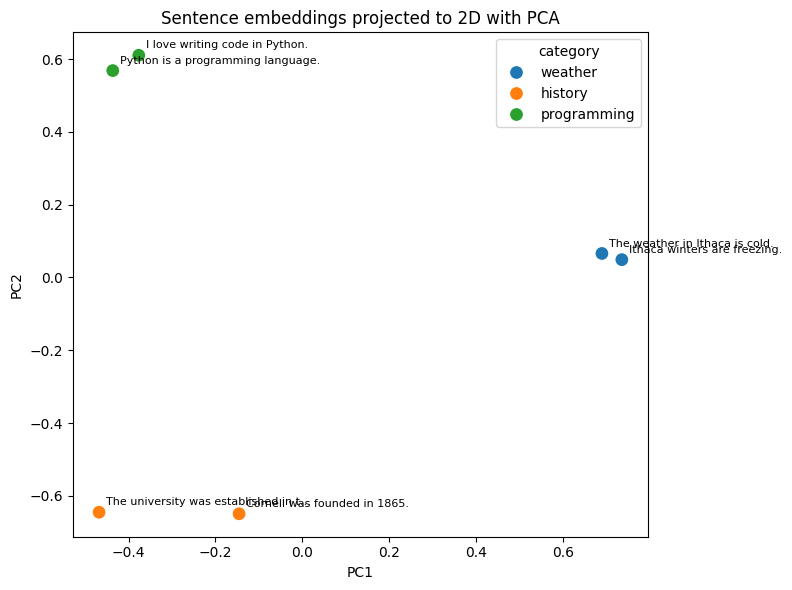

In [14]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
projected = pca.fit_transform(all_embeddings.numpy())

categories = ["weather", "weather", "history", "history", "programming", "programming"]
proj_df = pd.DataFrame(projected, columns=["PC1", "PC2"])
proj_df["category"] = categories
proj_df["sentence"] = [s[:35] + "..." if len(s) > 35 else s for s in all_sentences]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=proj_df, x="PC1", y="PC2", hue="category", s=100)

for _, row in proj_df.iterrows():
    plt.annotate(row["sentence"], (row["PC1"], row["PC2"]),
                 textcoords="offset points", xytext=(5, 5), fontsize=8)

plt.title("Sentence embeddings projected to 2D with PCA")
plt.tight_layout()

## Sentence-Transformers

Everything we just did by hand — loading the model, mean pooling, normalizing — is packaged up in the `sentence-transformers` library. Let's see what that looks like.

In [15]:
from sentence_transformers import SentenceTransformer

st_model = SentenceTransformer("all-MiniLM-L6-v2")

st_embeddings = st_model.encode(all_sentences, convert_to_tensor=True)
print("Shape:", st_embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Shape: torch.Size([6, 384])


In [16]:
torch.allclose(all_embeddings.cpu(), st_embeddings.cpu(), atol=1e-4)

True

In [17]:
st_model.similarity(st_embeddings, st_embeddings)

tensor([[ 1.0000,  0.8574,  0.1820, -0.0305,  0.1340,  0.1562],
        [ 0.8574,  1.0000,  0.1641, -0.0730,  0.0738,  0.1093],
        [ 0.1820,  0.1641,  1.0000,  0.4812,  0.0145,  0.0168],
        [-0.0305, -0.0730,  0.4812,  1.0000,  0.0823,  0.0030],
        [ 0.1340,  0.0738,  0.0145,  0.0823,  1.0000,  0.7154],
        [ 0.1562,  0.1093,  0.0168,  0.0030,  0.7154,  1.0000]],
       device='cuda:0')

Under the hood, `sentence-transformers` is doing exactly what we just built: loading a transformer, running a forward pass, pooling, and normalizing. Now that you understand the mechanics, this is the practical tool you'd reach for.

### Limitations of Embedding Similarity

Embedding models are powerful, but they aren't perfect. Let's look at a few cases where cosine similarity can be misleading.

In [21]:
failure_pairs = [
    ("I love Ithaca.", "I hate Ithaca."),
    ("The food in Ithaca is amazing.", "The food in Ithaca is terrible."),
    ("Cornell is a university.", "Cornell is a university located on East Hill in Ithaca, New York, overlooking the city and Cayuga Lake, with a campus spanning approximately 2,300 acres and facilities in New York City, Washington D.C., and Qatar."),
]

pair_embeddings = st_model.encode(
    [s for pair in failure_pairs for s in pair], convert_to_tensor=True
)

for i, (a, b) in enumerate(failure_pairs):
    sim = st_model.similarity(pair_embeddings[2*i].unsqueeze(0), pair_embeddings[2*i+1].unsqueeze(0))
    print(f"Pair {i+1}: {sim.item():.4f}")
    print(f"  A: {a}")
    print(f"  B: {b}")
    print()

Pair 1: 0.8774
  A: I love Ithaca.
  B: I hate Ithaca.

Pair 2: 0.7317
  A: The food in Ithaca is amazing.
  B: The food in Ithaca is terrible.

Pair 3: 0.7974
  A: Cornell is a university.
  B: Cornell is a university located on East Hill in Ithaca, New York, overlooking the city and Cayuga Lake, with a campus spanning approximately 2,300 acres and facilities in New York City, Washington D.C., and Qatar.



**Negation:** "I love Ithaca" and "I hate Ithaca" have very high similarity despite having opposite meanings. Embedding models tend to encode *topic* much more strongly than *sentiment* or *negation*. Both sentences are "about Ithaca and feelings," and the model treats them as similar.

**Length mismatch:** A short sentence and a long sentence about the same topic can still have high similarity, but the long sentence's embedding is "diluted" across more concepts. This can affect retrieval: a short, focused query might not match a long, detailed passage as well as you'd expect.

These are real limitations to keep in mind when building retrieval systems. They don't make embeddings useless (they're still often better than keyword matchinga) but they mean you shouldn't blindly trust similarity scores.

## Retrieval

Now let's use embeddings for something practical. We have a collection of short passages about Cornell and Ithaca. We'll embed all of them, then given a question, find the most relevant passages. This is the "retrieval" step in Retrieval-Augmented Generation.

In [20]:
import json

with open("data/cornell_ithaca_corpus.json") as f:
    corpus = json.load(f)

print(f"{len(corpus)} passages loaded\n")
for doc in corpus[:3]:
    print(f"[{doc['title']}]\n{doc['text']}\n")

18 passages loaded

[Cornell University - Founding]
Cornell University was founded in 1865 by Ezra Cornell and Andrew Dickson White. Its founding principle was to create an institution where any person could find instruction in any study. It was inaugurated on October 7, 1868, with 412 students.

[Cornell University - Location]
Cornell's main campus is located on East Hill in Ithaca, New York, overlooking the city and Cayuga Lake. The campus spans approximately 2,300 acres. Cornell also maintains facilities in New York City, Washington D.C., and Qatar.

[Cornell University - Ivy League and Land Grant]
Cornell is a member of the Ivy League and is the federal land-grant institution of New York State. It is unique among Ivy League schools in having both privately endowed and state-supported statutory colleges. This dual structure reflects its land-grant mission of public engagement.



In [22]:
corpus_texts = [doc["text"] for doc in corpus]
corpus_embeddings = st_model.encode(corpus_texts, convert_to_tensor=True)

print("Corpus embeddings shape:", corpus_embeddings.shape)

Corpus embeddings shape: torch.Size([18, 384])


Now we can write a simple retrieval function. Given a query, we embed it, compute cosine similarity against every passage, and return the top $k$ results.

In [23]:
def retrieve(query, corpus_embeddings, corpus, model, k=3):
    query_embedding = model.encode(query, convert_to_tensor=True)
    similarities = model.similarity(query_embedding, corpus_embeddings).squeeze()
    top_k = similarities.argsort(descending=True)[:k]

    results = []
    for idx in top_k:
        results.append({
            "title": corpus[idx]["title"],
            "text": corpus[idx]["text"],
            "score": similarities[idx].item()
        })
    return results

Let's try it out.

In [24]:
results = retrieve("What are the gorges near campus?", corpus_embeddings, corpus, st_model)

for r in results:
    print(f"[{r['score']:.3f}] {r['title']}")
    print(f"  {r['text']}\n")

[0.523] Ithaca - Gorges and Waterfalls
  Ithaca is famous for its dramatic gorges and waterfalls. Cascadilla Gorge runs through the center of the city, connecting the Cornell campus to downtown. Other notable gorges include Fall Creek Gorge on campus, featuring Ithaca Falls, the largest waterfall in the region.

[0.402] Ithaca - Outdoor Recreation
  Ithaca offers extensive outdoor recreation including the 8-mile Cayuga Waterfront Trail along the southern shore of Cayuga Lake and the 8.5-mile Black Diamond Trail. Buttermilk Falls State Park and Robert H. Treman State Park provide additional hiking, swimming, and camping opportunities.

[0.340] Cornell University - Location
  Cornell's main campus is located on East Hill in Ithaca, New York, overlooking the city and Cayuga Lake. The campus spans approximately 2,300 acres. Cornell also maintains facilities in New York City, Washington D.C., and Qatar.



In [25]:
results = retrieve("Where can I eat near Cornell?", corpus_embeddings, corpus, st_model)

for r in results:
    print(f"[{r['score']:.3f}] {r['title']}")
    print(f"  {r['text']}\n")

[0.595] Cornell University - Location
  Cornell's main campus is located on East Hill in Ithaca, New York, overlooking the city and Cayuga Lake. The campus spans approximately 2,300 acres. Cornell also maintains facilities in New York City, Washington D.C., and Qatar.

[0.490] Cornell University - Research
  Cornell is classified as a research university with very high research activity. The university operates major research facilities including the Cornell High Energy Synchrotron Source and the Cornell NanoScale Science and Technology Facility. Annual research expenditures exceed one billion dollars.

[0.488] Ithaca - Educational Institutions
  In addition to Cornell University, Ithaca is home to Ithaca College, located on South Hill with panoramic views of Cayuga Lake. The city's population roughly doubles when students are in session. Ithaca's identity is deeply shaped by its role as a college town.



In [26]:
results = retrieve("How do neural networks learn?", corpus_embeddings, corpus, st_model)

for r in results:
    print(f"[{r['score']:.3f}] {r['title']}")
    print(f"  {r['text']}\n")

[0.072] Cornell University - Founding
  Cornell University was founded in 1865 by Ezra Cornell and Andrew Dickson White. Its founding principle was to create an institution where any person could find instruction in any study. It was inaugurated on October 7, 1868, with 412 students.

[0.051] Cornell University - Colleges and Schools
  Cornell has fourteen colleges and schools, offering more than 80 undergraduate majors and over 120 graduate fields of study. These include the College of Arts and Sciences, the College of Engineering, the College of Agriculture and Life Sciences, and the Nolan School of Hotel Administration, among others.

[0.037] Ithaca - Taughannock Falls
  Taughannock Falls State Park, located just north of Ithaca, is home to Taughannock Falls. At 215 feet, it is the tallest single-drop waterfall east of the Rocky Mountains, taller than Niagara Falls. The park offers hiking trails, swimming, and cross-country skiing.



Notice how the similarity scores for the out-of-scope query are noticeably lower — the model correctly identifies that none of our passages are very relevant to neural networks. In a real system, you could use a score threshold to decide whether retrieved passages are worth including.

## Completing the RAG Pipeline

We started this lecture by asking Qwen a question it couldn't answer. Now we have all the pieces to fix that. The idea is simple: retrieve relevant passages, put them in the prompt as context, and ask the model to answer based on that context.

In [31]:
def ask_with_rag(question, corpus_embeddings, corpus, retrieval_model, gen_model, gen_tokenizer, k=3):
    results = retrieve(question, corpus_embeddings, corpus, retrieval_model, k=k)
    
    context = "\n\n".join([r["text"] for r in results])
    
    prompt = f"""Answer the following question using only the provided context. If the context doesn't contain enough information to answer, say so.

Context:
{context}

Question: {question}"""
    
    messages = [{"role": "user", "content": prompt}]
    inputs = gen_tokenizer.apply_chat_template(messages, return_tensors="pt", add_generation_prompt=True)
    
    with torch.no_grad():
        output = gen_model.generate(**inputs, max_new_tokens=200, do_sample=False)
    
    response = gen_tokenizer.decode(output[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True)
    
    print("Retrieved passages:")
    for r in results:
        print(f"  [{r['score']:.3f}] {r['title']}")
    print(f"\nQuestion: {question}")
    print(f"\nAnswer: {response}")

Let's try our original question, plus a couple more.

In [32]:
ask_with_rag(
    "Tell me about Cornell University.",
    corpus_embeddings, corpus, st_model, model, tokenizer
)

Retrieved passages:
  [0.732] Cornell University - Ivy League and Land Grant
  [0.712] Cornell University - Founding
  [0.701] Cornell University - Colleges and Schools

Question: Tell me about Cornell University.

Answer: Cornell University is a prestigious educational institution located in Ithaca, New York, United States. Founded in 1865 by Ezra Cornell and Andrew Dickson White, it was established with the principle of providing education across various disciplines, aiming for inclusivity and accessibility. The university is part of the Ivy League and serves as the federal land-grant institution for the state of New York.

Cornell's unique structure includes both privately endowed and state-supported colleges, reflecting its mission to engage with the public. This dual funding model underscores its commitment to public service and education.

The university offers a wide range of academic programs, including over 80 undergraduate majors and over 120 graduate fields of study. Some no

In [33]:
ask_with_rag(
    "What waterfalls can I visit near Cornell?",
    corpus_embeddings, corpus, st_model, model, tokenizer
)

Retrieved passages:
  [0.668] Ithaca - Gorges and Waterfalls
  [0.560] Cornell University - Location
  [0.484] Ithaca - Outdoor Recreation

Question: What waterfalls can I visit near Cornell?

Answer: Near Cornell, you can visit Ithaca Falls, which is part of Fall Creek Gorge on the Cornell campus. This is the largest waterfall in the region according to the provided context.


In [34]:
ask_with_rag(
    "How do I train a neural network?",
    corpus_embeddings, corpus, st_model, model, tokenizer
)

Retrieved passages:
  [0.062] Cornell University - Founding
  [0.034] Cornell University - Location
  [0.017] Cornell University - Ivy League and Land Grant

Question: How do I train a neural network?

Answer: The provided context does not contain any information related to training a neural network. The context is about Cornell University's history, location, and affiliations. To answer how to train a neural network, I would need to provide information about the process, which typically involves selecting an appropriate architecture, choosing an optimization algorithm, setting up the learning rate, defining the loss function, preparing the dataset, and iterating through the training process to minimize the loss. If you need this information, I can certainly provide it.


Compare these answers to the response at the beginning of the lecture. The model's answers are now grounded in the retrieved documents. When the context doesn't contain relevant information (like the neural network question), the model can say so rather than making something up.

This retrieve-then-generate pattern is **Retrieval-Augmented Generation (RAG)**. The basic version we built today is already useful, but there's a lot of room for improvement: better chunking strategies, more documents, reranking retrieved results, score thresholds for filtering, and more sophisticated prompting.